# Chapter 8 notebook — Sensor anomaly detection

Walks through Chapter 11 + the `project_03_sensor_anomaly_detection` project, interactively. We use the synthetic vibration dataset, train a tiny autoencoder, choose a threshold, and visualize where anomalies are detected.

Before running: `cd projects/project_03_sensor_anomaly_detection && python generate_synthetic.py` to produce the data files in `datasets/`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
sys.path.insert(0, str(Path('../projects/project_03_sensor_anomaly_detection').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import torch

from train_autoencoder import TinyAutoencoder, windowize

DATA = Path('../datasets')
normal = np.load(DATA / 'vibration_normal.npy')
anomaly = np.load(DATA / 'vibration_anomaly.npy')
print('normal:', normal.shape, '| anomaly:', anomaly.shape)
RATE = 1000  # Hz

normal: (20000, 3) | anomaly: (10000, 3)


## 1. Look at the raw signal

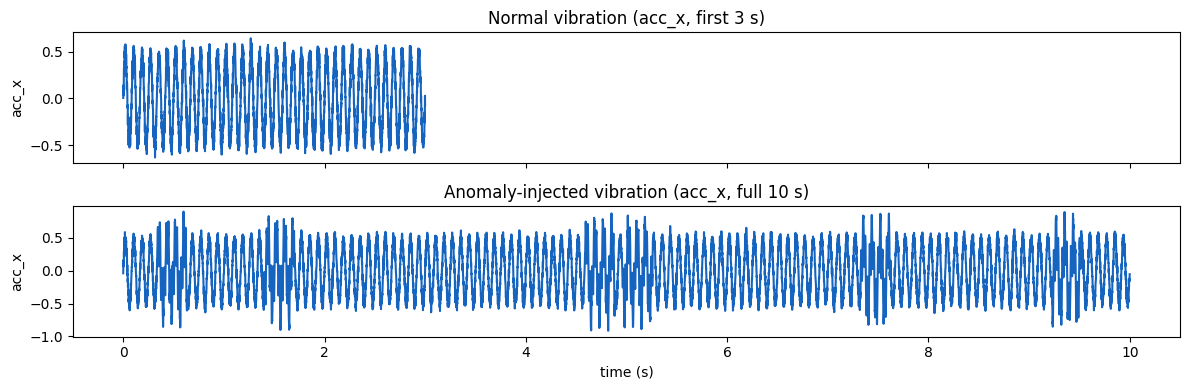

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
t_n = np.arange(len(normal)) / RATE
t_a = np.arange(len(anomaly)) / RATE
axes[0].plot(t_n[:3000], normal[:3000, 0], color='#1565C0')
axes[0].set_title('Normal vibration (acc_x, first 3 s)')
axes[0].set_ylabel('acc_x')
axes[1].plot(t_a, anomaly[:, 0], color='#1565C0')
axes[1].set_title('Anomaly-injected vibration (acc_x, full 10 s)')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('acc_x')
plt.tight_layout()
plt.show()

## 2. Window the signal

In [3]:
WIN, STRIDE = 128, 64
train_w = windowize(normal[:int(0.8 * len(normal))], WIN, STRIDE)
val_w   = windowize(normal[int(0.8 * len(normal)):], WIN, STRIDE)
test_w  = windowize(anomaly, WIN, STRIDE)
print('train:', train_w.shape, '| val(normal):', val_w.shape, '| test(anomaly):', test_w.shape)

train: (249, 384) | val(normal): (61, 384) | test(anomaly): (155, 384)


## 3. Load the pretrained autoencoder and compute reconstruction error

In [4]:
ckpt = torch.load('../projects/project_03_sensor_anomaly_detection/results/autoencoder.pt',
                  map_location='cpu', weights_only=False)
model = TinyAutoencoder(in_dim=ckpt['in_dim'], latent_dim=ckpt['config']['latent_dim'])
model.load_state_dict(ckpt['state_dict'])
model.eval()
threshold = float(ckpt['threshold'])
print(f'threshold from held-out normal (q99): {threshold:.5f}')

def recon_error(model, w):
    with torch.no_grad():
        x = torch.from_numpy(w)
        r = model(x)
        return ((x - r) ** 2).mean(dim=1).numpy()

err_val = recon_error(model, val_w)
err_test = recon_error(model, test_w)
print(f'val(normal)  recon err: mean={err_val.mean():.5f}  q99={np.quantile(err_val, 0.99):.5f}')
print(f'test(anomaly) recon err: mean={err_test.mean():.5f}  q99={np.quantile(err_test, 0.99):.5f}')

threshold from held-out normal (q99): 0.00308
val(normal)  recon err: mean=0.00260  q99=0.00308
test(anomaly) recon err: mean=0.01203  q99=0.05531


## 4. Distribution of reconstruction error

Anomaly windows should produce a higher reconstruction error than normal windows. If the two distributions barely overlap, anomaly detection works. If they overlap a lot, the model has not separated them — try more epochs, more latent capacity, or better features.

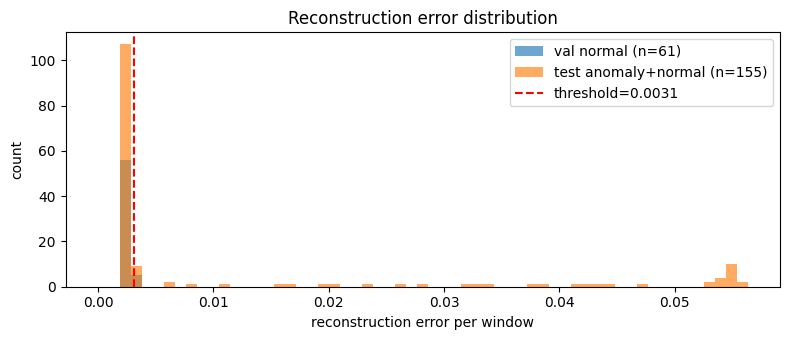

In [5]:
plt.figure(figsize=(8, 3.5))
bins = np.linspace(0, max(err_val.max(), err_test.max()), 60)
plt.hist(err_val, bins=bins, alpha=0.65, label=f'val normal (n={len(err_val)})')
plt.hist(err_test, bins=bins, alpha=0.65, label=f'test anomaly+normal (n={len(err_test)})')
plt.axvline(threshold, color='red', linestyle='--', label=f'threshold={threshold:.4f}')
plt.xlabel('reconstruction error per window')
plt.ylabel('count')
plt.title('Reconstruction error distribution')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Mark windows above threshold on the test stream

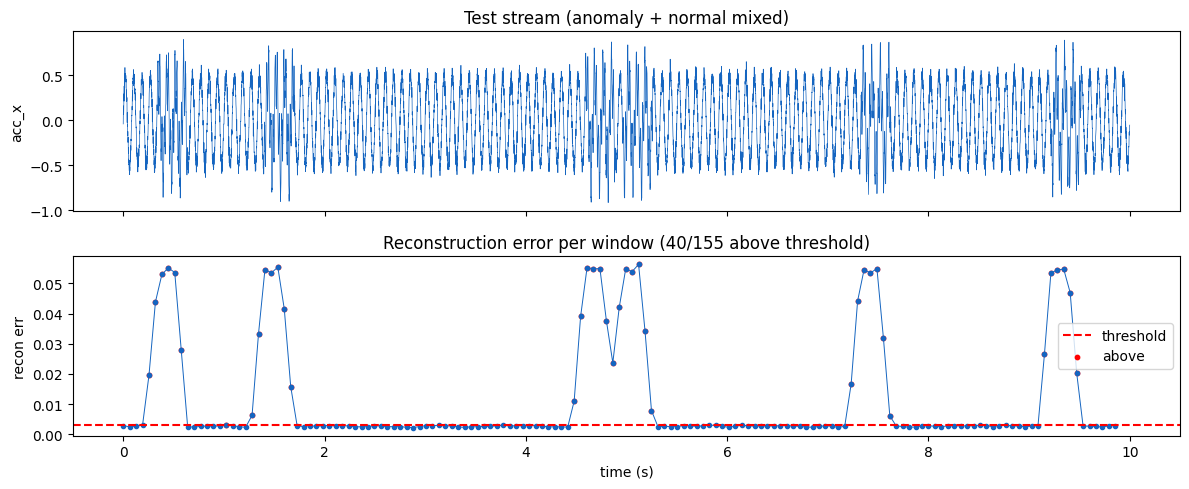

In [6]:
win_times = np.arange(len(test_w)) * STRIDE / RATE
above = err_test > threshold

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(np.arange(len(anomaly)) / RATE, anomaly[:, 0], linewidth=0.5, color='#1565C0')
axes[0].set_ylabel('acc_x')
axes[0].set_title('Test stream (anomaly + normal mixed)')
axes[1].plot(win_times, err_test, marker='.', linestyle='-', linewidth=0.7, color='#1565C0')
axes[1].axhline(threshold, color='red', linestyle='--', label=f'threshold')
axes[1].scatter(win_times[above], err_test[above], color='red', s=10, label='above')
axes[1].set_ylabel('recon err')
axes[1].set_xlabel('time (s)')
axes[1].set_title(f'Reconstruction error per window ({above.sum()}/{len(above)} above threshold)')
axes[1].legend()
plt.tight_layout()
plt.show()

## Take-aways

1. Windowing + a tiny autoencoder is a strong baseline for anomaly detection on sensor streams.
2. Always pick the threshold on **held-out normal** data, not training data.
3. Use a consecutive-windows rule (e.g. K=2 in a row) to suppress single-window spikes (the `infer_stream.py` script does this).
4. For real edge deployment, the model and the windowing run in a tight loop on a low-power device (Pi, Jetson, or MCU); only the alerts go upstream.